EE5121 - Convex Optimization  
Assignment 2 - Question 1

In [1]:
#imports
import numpy as np
import pandas as pd
import cvxpy as cp
import matplotlib.pyplot as plt
from scipy.optimize import minimize,LinearConstraint
from scipy.special import logsumexp

np.random.seed(0)

In [2]:
#Constant matrix Phi and vector mu
Phi = pd.read_csv('Phi_Q1.csv', header=0)
Phi = np.asarray(Phi[['phi_1','phi_2']].values.astype(float))
n,k = Phi.shape
mu = pd.read_csv('mu_Q1.csv', header=0)
mu = np.asarray(mu[['mu_1','mu_2']].values.astype(float))

Primal problem

In [3]:
#Decision variabless
p = cp.Variable(n, nonneg=True)

In [4]:
#Formulating the problem
entropy = cp.sum(cp.entr(p))
constraints = [Phi.T @ p == mu, cp.sum(p) == 1, p >= 0]
prob_primal = cp.Problem(cp.Maximize(entropy), constraints)


In [5]:
#Solution to the primal problem using cvxpy
print("Primal optimal objective value:", prob_primal.solve())
print("Optimal variable value:",p.value)
pstar = p.value
sum(p.value)


Primal optimal objective value: 2.2700535901750643
Optimal variable value: [0.10321059 0.12905737 0.13713966 0.1340683  0.11262096 0.08791025
 0.07328265 0.07472969 0.066318   0.08166253]


d:\MS IITM\3rdSem - JulNov2025\EE5121_ConvexOptimization\cvxvenv\Lib\site-packages\cvxpy\reductions\solvers\solving_chain_utils.py:30: UserWarning: The problem includes expressions that don't support CPP backend. Defaulting to the SCIPY backend for canonicalization.
  warnings.warn(UserWarning(


np.float64(0.9999999988202593)

Decision variable, primal objective, and infeasibility iterates 

In [6]:
#Helper functions
def safe_log(x):
    return np.log(np.maximum(x, 1e-16))

def obj_fun(p):
    return np.sum(p * safe_log(p))

def obj_grad(p):
    return safe_log(p) + 1

def moment_violation(p):
    return Phi.T.dot(p) - mu

def probability_unity_sum_violation(p):
    return np.sum(p) - 1

In [7]:
#Constraints and bounds
mom_cons = LinearConstraint(Phi.T, mu.ravel(), mu.ravel())
sum_cons = LinearConstraint(np.ones((1, Phi.T.shape[1])), 1.0, 1.0)
bounds = [(0.0, None)] * n

In [8]:
# Trackers for iterates
p_iters = []
H_iters = []
mom_resid_iters = []
sum_resid_iters = []
obj_iters = []

In [9]:
#Scipy callback function to store iterates
def callback(xk,second=None):
    p = np.maximum(xk, 0.0)  
    p_normed = p
    p_iters.append(p_normed.copy())
    H = -np.sum(p_normed * safe_log(p_normed))
    H_iters.append(H)
    mom_resid_iters.append(np.linalg.norm(Phi.T.dot(p_normed) - mu))
    sum_resid_iters.append(abs(np.sum(p_normed) - 1.0))
    obj_iters.append(obj_fun(p_normed))

In [10]:
#Initial guess
p0 = np.ones(n) / n
x0 = p0.copy()

In [11]:
#Solution with iterates tracked, using scipy
res = minimize(
    fun=obj_fun,
    x0=x0,
    jac=obj_grad,
    bounds=bounds,
    constraints=[mom_cons, sum_cons],
    method='trust-constr',   # use 'trust-constr' or 'SLSQP' if you prefer
    callback=callback,
    options={'verbose': 2, 'maxiter': 500}
)


| niter |f evals|CG iter|  obj func   |tr radius |   opt    |  c viol  |
|-------|-------|-------|-------------|----------|----------|----------|
|   1   |   1   |   0   | -2.3026e+00 | 1.00e+00 | 9.16e-16 | 1.95e-01 |
|   2   |   2   |   0   | -2.3000e+00 | 5.60e+00 | 1.13e-03 | 1.40e-01 |
|   3   |   3   |   1   | -2.7275e+00 | 1.05e+01 | 1.45e-03 | 3.94e-01 |
|   4   |   4   |   2   | -2.3744e+00 | 1.05e+01 | 1.10e-03 | 7.85e-02 |
|   5   |   5   |   3   | -2.3060e+00 | 1.05e+01 | 3.51e-04 | 2.68e-02 |
|   6   |   5   |   3   | -2.3060e+00 | 5.26e+01 | 1.68e-04 | 2.68e-02 |
|   7   |   6   |   4   | -2.2700e+00 | 5.26e+01 | 6.66e-05 | 2.22e-16 |
|   8   |   6   |   4   | -2.2700e+00 | 2.63e+02 | 3.81e-05 | 2.22e-16 |
|   9   |   6   |   4   | -2.2700e+00 | 1.32e+03 | 4.45e-05 | 2.22e-16 |
|  10   |   6   |   4   | -2.2700e+00 | 6.58e+03 | 4.58e-05 | 2.22e-16 |
|  11   |   7   |   6   | -2.2701e+00 | 6.58e+03 | 1.42e-05 | 2.78e-17 |
|  12   |   8   |   8   | -2.2701e+00 | 6.58e+03 | 

In [12]:
#Numpyfication for plotting
H_arr = np.array(H_iters)
mom_arr = np.array(mom_resid_iters)
sum_arr = np.array(sum_resid_iters)
it = np.arange(len(H_arr))

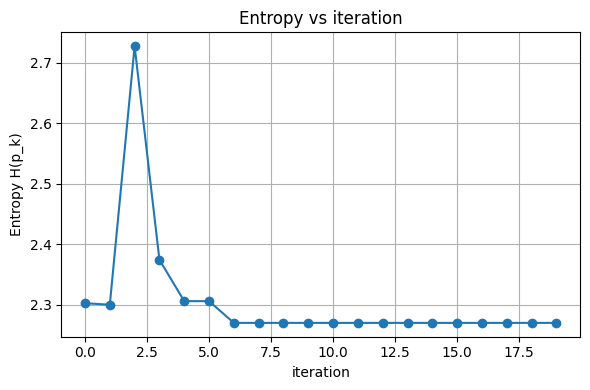

In [13]:
#Entropy plot
plt.figure(figsize=(6,4))
plt.plot(it, H_arr, '-o')
plt.xlabel('iteration')
plt.ylabel('Entropy H(p_k)')
plt.title('Entropy vs iteration')
plt.grid(True)
plt.tight_layout()
plt.savefig('q1_entropy_scipy.png', dpi=200)

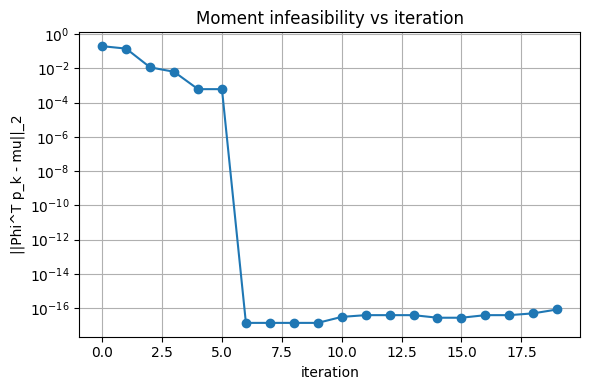

In [14]:
#Moment constraint infeasibility plot
plt.figure(figsize=(6,4))
plt.semilogy(it, mom_arr, '-o')
plt.xlabel('iteration')
plt.ylabel('||Phi^T p_k - mu||_2')
plt.title('Moment infeasibility vs iteration')
plt.grid(True)
plt.tight_layout()
plt.savefig('q1_moment_infeas_scipy.png', dpi=200)

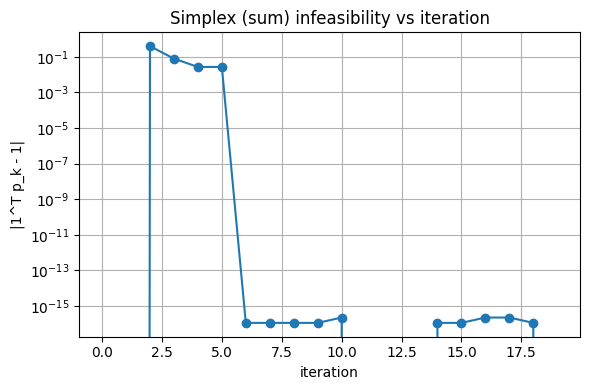

In [15]:
#Probability unity sum infeasibility plot
plt.figure(figsize=(6,4))
plt.semilogy(it, sum_arr, '-o')
plt.xlabel('iteration')
plt.ylabel('|1^T p_k - 1|')
plt.title('Simplex (sum) infeasibility vs iteration')
plt.grid(True)
plt.tight_layout()
plt.savefig('q1_sum_infeas_scipy.png', dpi=200)

(f) Dual problem

In [16]:
mu = mu.reshape(-1)

In [17]:
theta = cp.Variable(k)
obj = cp.log_sum_exp(Phi @ theta) - theta.T @ mu   
dual_prob = cp.Problem(cp.Minimize(obj))
dual_prob.solve()

np.float64(2.2700535918657496)

In [18]:
#Optimal dual variables
theta_star = np.asarray(theta.value).ravel()
ls = float(logsumexp(Phi @ theta_star))
nu_star = 1.0 - ls

In [19]:
#Optimal value of the dual function
g_theta = float(theta_star @ mu - ls)
# g(theta,nu) from the Lagrangian-maximized-over-p expression using relation p_i = exp(phi_i^T theta + nu - 1) and sum p = 1, the resulting dual equals g_theta.
g_theta_nu = g_theta

In [20]:
# construct p_tilde (Gibbs form)
logits = Phi @ theta_star
logits = logits - np.max(logits)   # numerical stability
p_tilde = np.exp(logits)
p_tilde /= p_tilde.sum()

In [21]:
# compute H(pstar) (entropy) and diagnostics
H_pstar = -np.sum(pstar * np.log(np.maximum(pstar, 1e-16)))
linf_diff = np.max(np.abs(pstar - p_tilde))
duality_gap = abs(H_pstar - g_theta_nu)

In [22]:
print("Dual solve status (CVXPY):", dual_prob.status)
print(f"theta* (shape): {theta_star.shape}")
print(f"nu* = {nu_star:.12g}")
print(f"g(theta*,nu*) = {g_theta_nu:.12g}")
print(f"H(p*) = {H_pstar:.12g}")
print(f"||p* - p_tilde||_inf = {linf_diff:.3e}")
print(f"duality gap |H(p*) - g(theta*,nu*)| = {duality_gap:.3e}")


Dual solve status (CVXPY): optimal
theta* (shape): (2,)
nu* = -1.34834205882
g(theta*,nu*) = -2.27005359187
H(p*) = 2.27005359018
||p* - p_tilde||_inf = 3.707e-06
duality gap |H(p*) - g(theta*,nu*)| = 4.540e+00
